In [2]:
from pathlib import Path
from collections import Counter
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

print("Imports successful!")

Imports successful!


Locate the dataset

In [3]:
DATASET_DIR = Path("../data/raw/garbage-dataset")

print("Dataset path:", DATASET_DIR.resolve())
print("Dataset exists:", DATASET_DIR.exists())

Dataset path: C:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\data\raw\garbage-dataset
Dataset exists: True


Discover the classes

In [4]:
class_names = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print(f"Number of classes: {len(class_names)}")
print("Classes:")

for class_name in class_names:
    print(f" - {class_name}")

Number of classes: 10
Classes:
 - battery
 - biological
 - cardboard
 - clothes
 - glass
 - metal
 - paper
 - plastic
 - shoes
 - trash


Build an image inventory

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for class_name in class_names:
    class_dir = DATASET_DIR / class_name

    for file_path in class_dir.iterdir():

        if file_path.is_file():

            records.append({
                "class_name": class_name,
                "file_name": file_path.name,
                "file_path": str(file_path),
                "extension": file_path.suffix.lower(),
                "is_supported_image": file_path.suffix.lower() in IMAGE_EXTENSIONS
            })

df_files = pd.DataFrame(records)

print("Total files:", len(df_files))
display(df_files.head())

Total files: 19762


,class_name,file_name,file_path,extension,is_supported_image
0,battery,battery_1.jpg,..\data\raw\garbage-dataset\battery\battery_1.jpg,.jpg,True
1,battery,battery_10.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True
2,battery,battery_100.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True
3,battery,battery_101.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True
4,battery,battery_102.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True


Check extensions

In [6]:
extension_counts = (
    df_files["extension"]
    .value_counts()
    .sort_values(ascending=False)
)

display(extension_counts)

extension
.jpg     19730
.png        31
.jpeg        1
Name: count, dtype: int64

In [7]:
unsupported_files = df_files[
    ~df_files["is_supported_image"]
]

print("Unsupported files:", len(unsupported_files))

if len(unsupported_files) > 0:
    display(unsupported_files)

Unsupported files: 0


Actual class distribution

In [8]:
class_counts = (
    df_files[df_files["is_supported_image"]]
    ["class_name"]
    .value_counts()
    .reindex(class_names)
)

class_distribution = pd.DataFrame({
    "class_name": class_counts.index,
    "image_count": class_counts.values
})

class_distribution["percentage"] = (
    class_distribution["image_count"]
    / class_distribution["image_count"].sum()
    * 100
)

display(class_distribution)

print(
    "Total supported images:",
    class_distribution["image_count"].sum()
)

,class_name,image_count,percentage
0,battery,944,4.776844
1,biological,997,5.045036
2,cardboard,1825,9.234895
3,clothes,5327,26.955774
4,glass,3061,15.489323
5,metal,1020,5.161421
6,paper,1680,8.501164
7,plastic,1984,10.039470
8,shoes,1977,10.004048
9,trash,947,4.792025


Total supported images: 19762


Visualize class imbalance

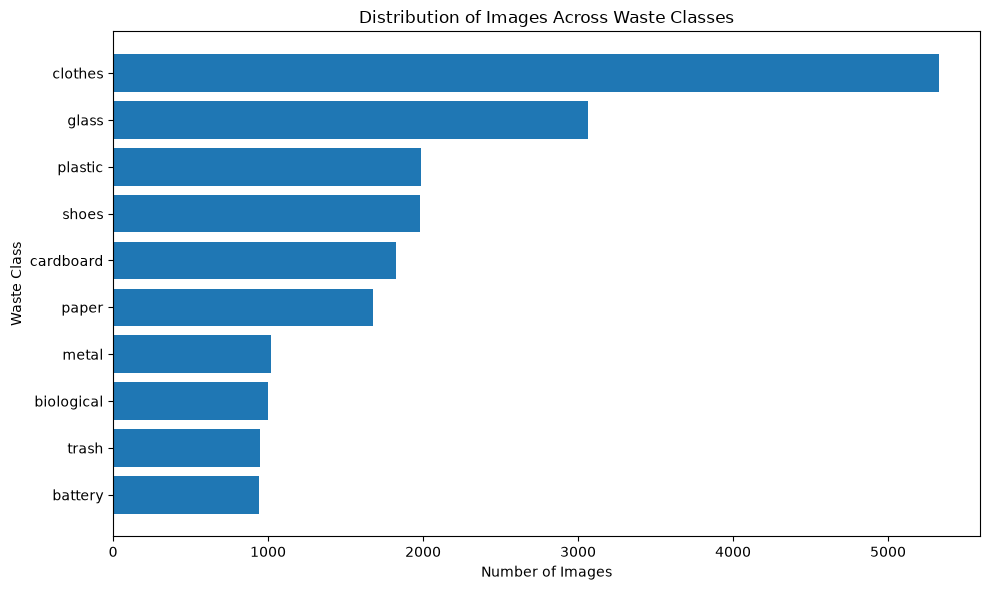

In [9]:
plot_df = class_distribution.sort_values(
    "image_count",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["class_name"],
    plot_df["image_count"]
)

plt.xlabel("Number of Images")
plt.ylabel("Waste Class")
plt.title("Distribution of Images Across Waste Classes")

plt.tight_layout()
plt.show()

Calculate imbalance statistics

In [10]:
largest_class = class_distribution.loc[
    class_distribution["image_count"].idxmax()
]

smallest_class = class_distribution.loc[
    class_distribution["image_count"].idxmin()
]

imbalance_ratio = (
    largest_class["image_count"]
    / smallest_class["image_count"]
)

print(
    f"Largest class: {largest_class['class_name']} "
    f"({largest_class['image_count']} images)"
)

print(
    f"Smallest class: {smallest_class['class_name']} "
    f"({smallest_class['image_count']} images)"
)

print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Largest class: clothes (5327 images)
Smallest class: battery (944 images)
Imbalance ratio: 5.64:1


Inspect image dimensions, modes, and corruption

In [11]:
image_metadata = []
corrupted_files = []

supported_df = df_files[df_files["is_supported_image"]].copy()

for idx, row in supported_df.iterrows():
    file_path = Path(row["file_path"])

    try:
        with Image.open(file_path) as img:
            img.verify()

        # Re-open after verify()
        with Image.open(file_path) as img:
            width, height = img.size
            mode = img.mode
            image_format = img.format

        image_metadata.append({
            "class_name": row["class_name"],
            "file_name": row["file_name"],
            "file_path": row["file_path"],
            "width": width,
            "height": height,
            "mode": mode,
            "format": image_format
        })

    except Exception as e:
        corrupted_files.append({
            "class_name": row["class_name"],
            "file_name": row["file_name"],
            "file_path": row["file_path"],
            "error": str(e)
        })

df_images = pd.DataFrame(image_metadata)
df_corrupted = pd.DataFrame(corrupted_files)

print("Successfully verified images:", len(df_images))
print("Corrupted/unreadable images:", len(df_corrupted))

Successfully verified images: 19762
Corrupted/unreadable images: 0


Image color modes

In [12]:
mode_counts = df_images["mode"].value_counts()

print("Image color modes:")
display(mode_counts)

Image color modes:


mode
RGB     19017
RGBA      724
P          18
CMYK        2
L           1
Name: count, dtype: int64

Image dimensions

In [13]:
dimension_counts = (
    df_images
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Number of unique image dimensions:", len(dimension_counts))

display(dimension_counts.head(20))

Number of unique image dimensions: 2731


,width,height,count
1257,400,533,2591
1900,512,384,2524
414,225,225,1924
1258,400,534,1077
630,275,183,671
571,259,194,521
1924,533,400,387
1365,400,711,300
1687,474,474,240
250,194,259,219


In [14]:
print("Width statistics:")
display(df_images["width"].describe())

print("Height statistics:")
display(df_images["height"].describe())

Width statistics:


count    19762.000000
mean       420.798806
std        294.167262
min         51.000000
25%        259.000000
50%        400.000000
75%        512.000000
max       7786.000000
Name: width, dtype: float64

Height statistics:


count    19762.000000
mean       431.642901
std        337.932944
min         71.000000
25%        225.000000
50%        384.000000
75%        533.000000
max       6283.000000
Name: height, dtype: float64

Aspect ratio

count    19762.000000
mean         1.069026
std          0.352546
min          0.127500
25%          0.750469
50%          1.000000
75%          1.333333
max          6.376344
Name: aspect_ratio, dtype: float64

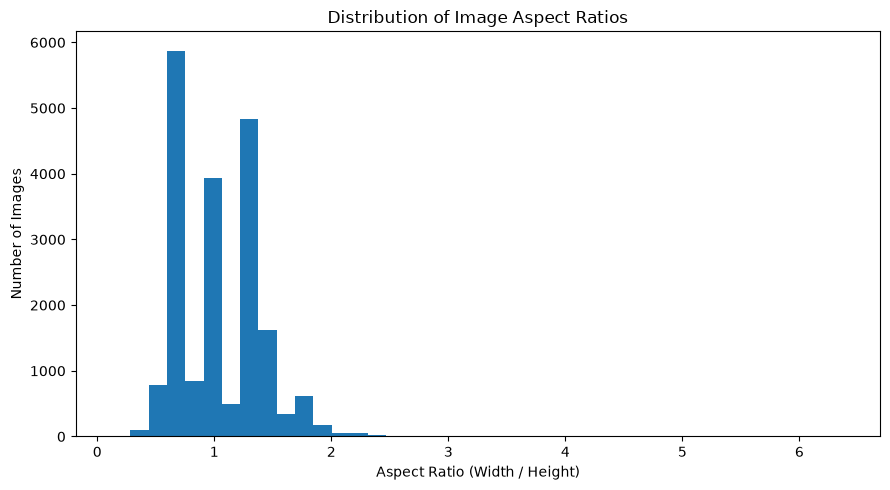

In [16]:
df_images["aspect_ratio"] = (
    df_images["width"] / df_images["height"]
)

display(df_images["aspect_ratio"].describe())

plt.figure(figsize=(9, 5))

plt.hist(
    df_images["aspect_ratio"],
    bins=40
)

plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Aspect Ratios")

plt.tight_layout()
plt.show()

Image resolution distribution

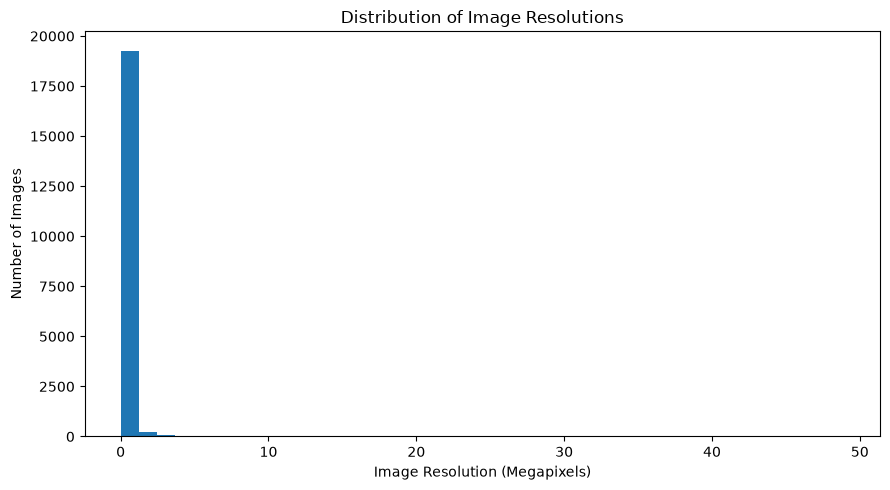

In [17]:
df_images["megapixels"] = (
    df_images["width"] * df_images["height"] / 1_000_000
)

plt.figure(figsize=(9, 5))

plt.hist(
    df_images["megapixels"],
    bins=40
)

plt.xlabel("Image Resolution (Megapixels)")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Resolutions")

plt.tight_layout()
plt.show()

Random visual samples from every class

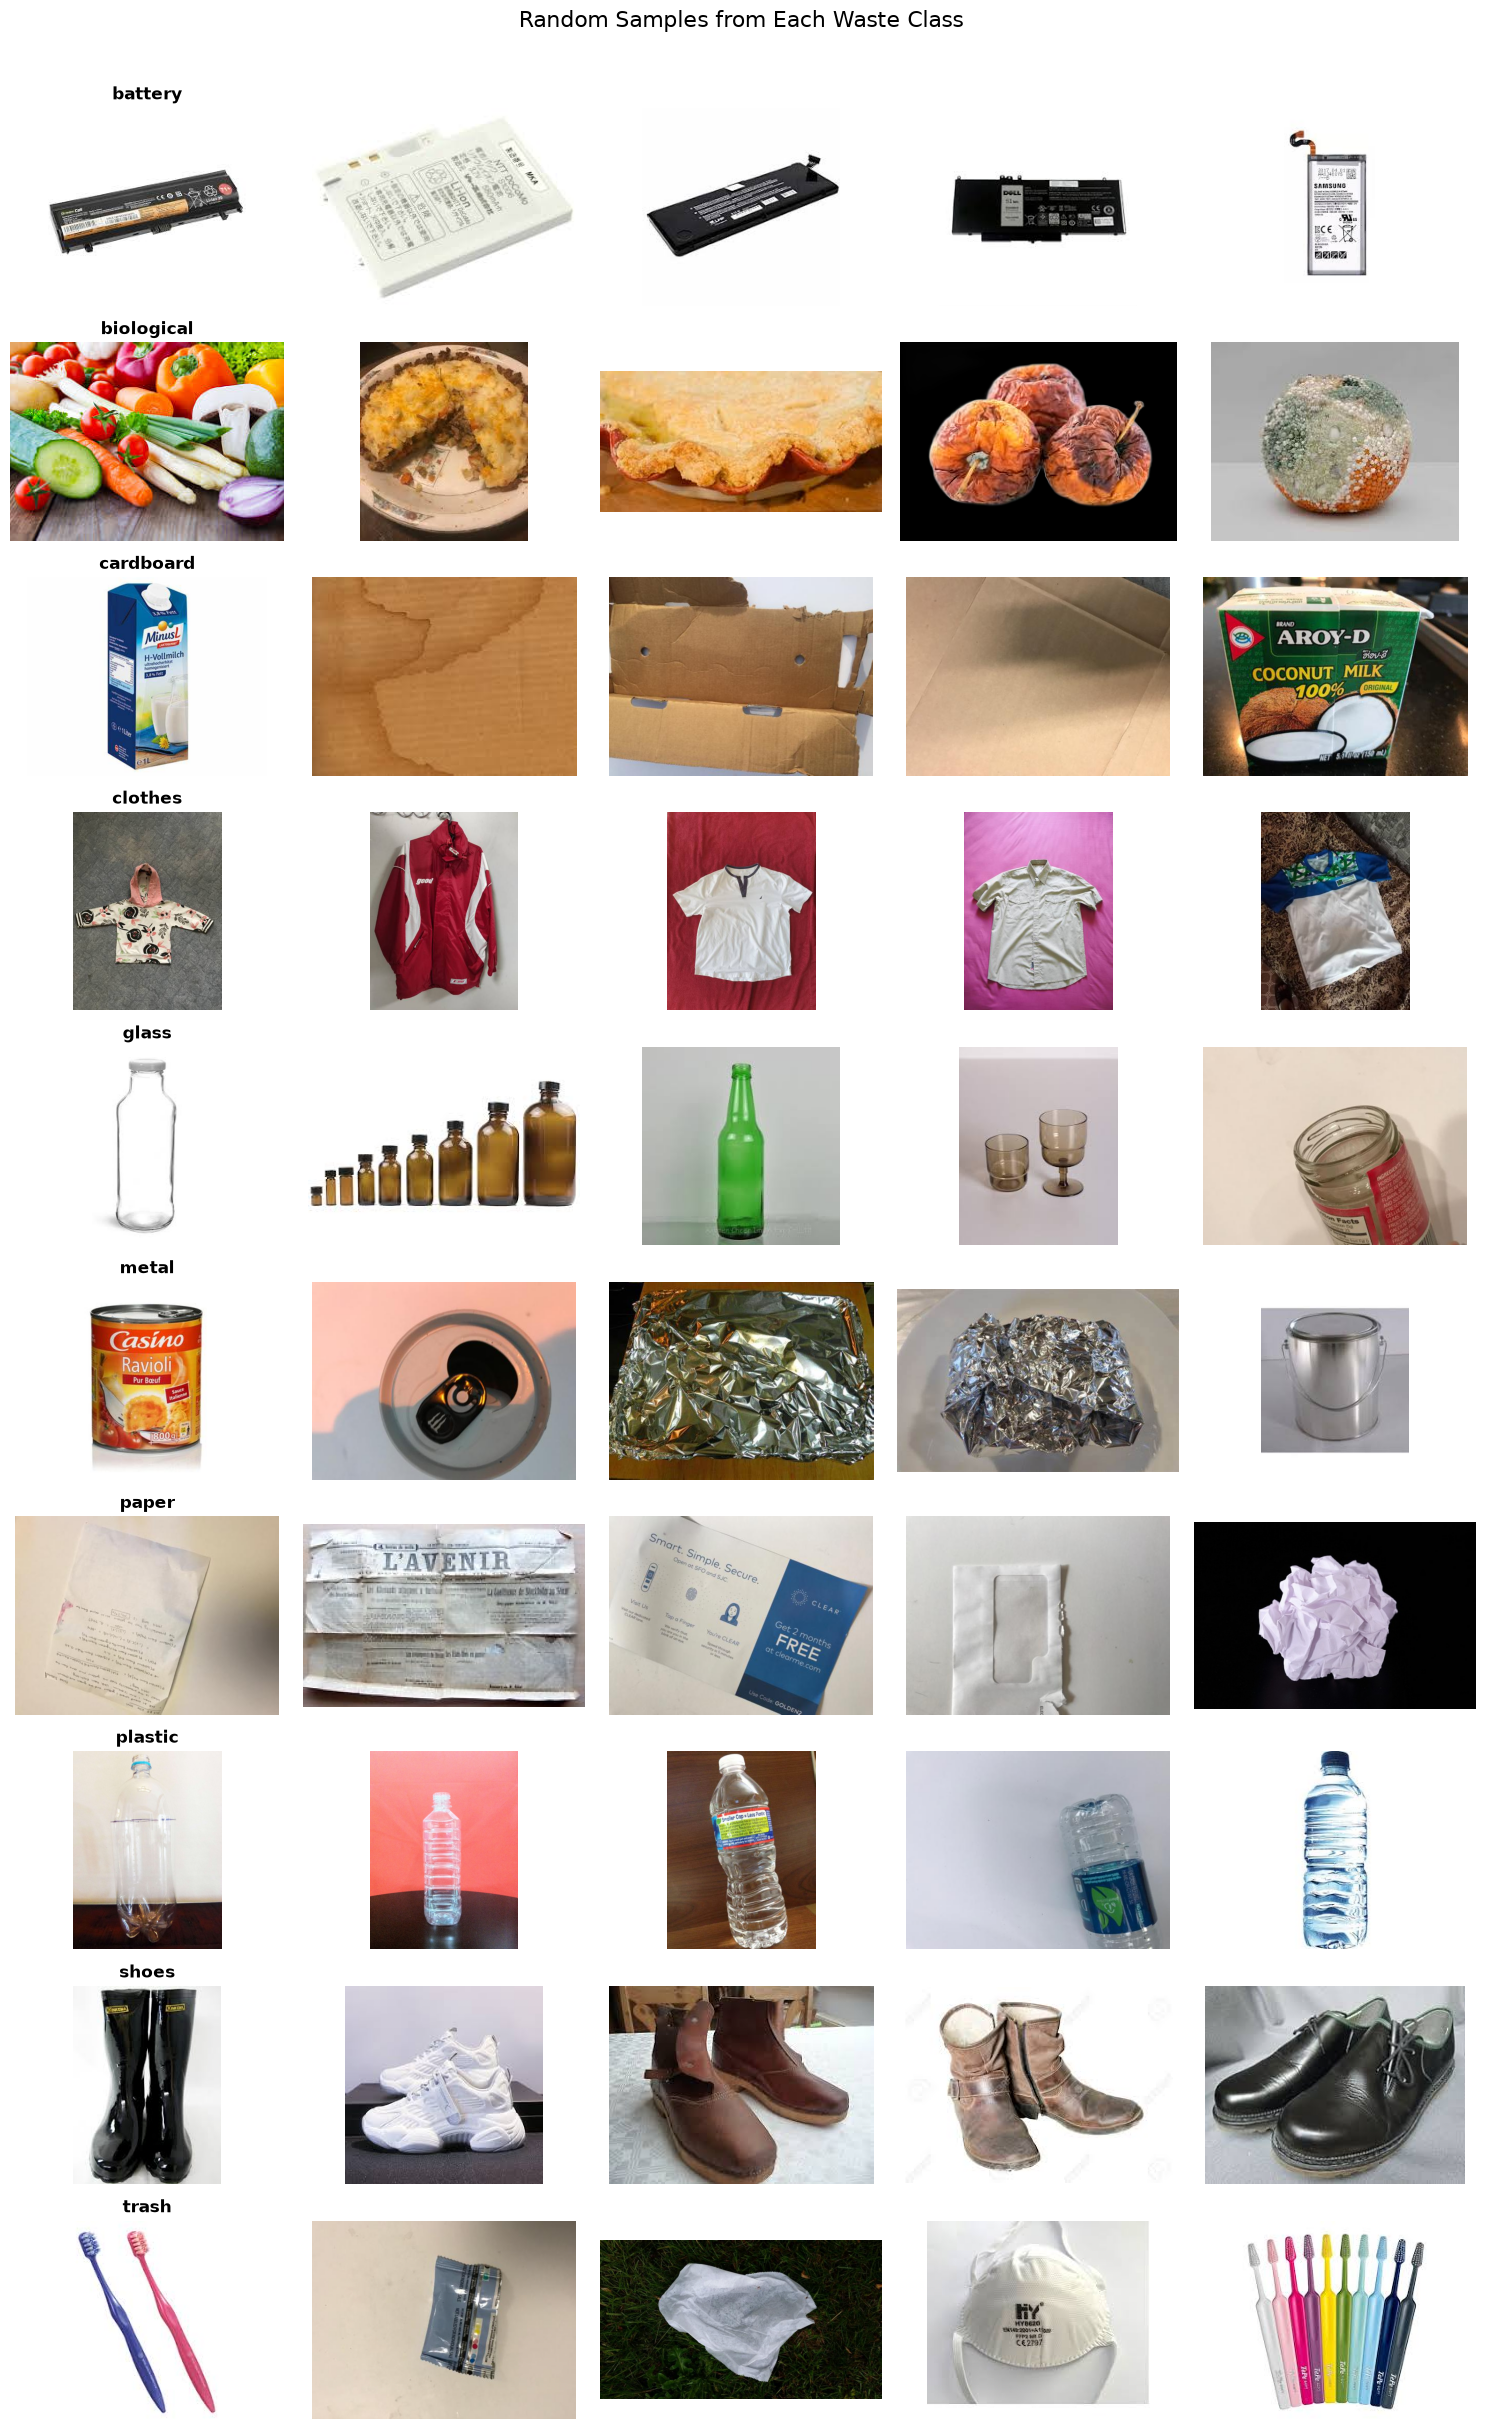

In [18]:
random.seed(42)

samples_per_class = 5

fig, axes = plt.subplots(
    len(class_names),
    samples_per_class,
    figsize=(15, 24)
)

for row_idx, class_name in enumerate(class_names):

    class_df = df_images[
        df_images["class_name"] == class_name
    ]

    sampled = class_df.sample(
        n=min(samples_per_class, len(class_df)),
        random_state=42
    )

    for col_idx, (_, image_row) in enumerate(sampled.iterrows()):

        image = Image.open(image_row["file_path"]).convert("RGB")

        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].axis("off")

        if col_idx == 0:
            axes[row_idx, col_idx].set_title(
                class_name,
                fontsize=12,
                fontweight="bold"
            )

plt.suptitle(
    "Random Samples from Each Waste Class",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

Exact duplicate detection

In [19]:
def calculate_sha256(file_path, chunk_size=8192):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


df_images["sha256"] = df_images["file_path"].apply(
    calculate_sha256
)

print("Hashes calculated:", len(df_images))

Hashes calculated: 19762


In [21]:
duplicate_mask = df_images.duplicated(
    subset="sha256",
    keep=False
)

exact_duplicates = (
    df_images[duplicate_mask]
    .sort_values("sha256")
)

print(
    "Images belonging to exact duplicate groups:",
    len(exact_duplicates)
)

print(
    "Number of unique duplicated hashes:",
    exact_duplicates["sha256"].nunique()
)

Images belonging to exact duplicate groups: 0
Number of unique duplicated hashes: 0


In [22]:
display(
    exact_duplicates[
        ["class_name", "file_name", "file_path", "sha256"]
    ].head(50)
)

,class_name,file_name,file_path,sha256


Check cross-class exact duplicates

In [24]:
duplicate_class_counts = (
    exact_duplicates
    .groupby("sha256")["class_name"]
    .nunique()
)

cross_class_hashes = duplicate_class_counts[
    duplicate_class_counts > 1
].index

cross_class_duplicates = exact_duplicates[
    exact_duplicates["sha256"].isin(cross_class_hashes)
]

print(
    "Exact duplicate groups appearing across different classes:",
    len(cross_class_hashes)
)

if len(cross_class_duplicates) > 0:
    display(
        cross_class_duplicates[
            ["class_name", "file_name", "file_path", "sha256"]
        ]
    )

Exact duplicate groups appearing across different classes: 0


Calculate perceptual hashes

In [25]:
import imagehash
from tqdm.auto import tqdm

perceptual_hashes = []

for _, row in tqdm(
    df_images.iterrows(),
    total=len(df_images),
    desc="Calculating perceptual hashes"
):
    try:
        with Image.open(row["file_path"]) as img:
            img = img.convert("RGB")
            phash = imagehash.phash(img)

        perceptual_hashes.append(str(phash))

    except Exception:
        perceptual_hashes.append(None)

df_images["phash"] = perceptual_hashes

print("Perceptual hashes calculated:", df_images["phash"].notna().sum())

Calculating perceptual hashes:   0%|          | 0/19762 [00:00<?, ?it/s]

Perceptual hashes calculated: 19762


Find identical perceptual hashes

In [26]:
phash_duplicates = df_images[
    df_images.duplicated(
        subset="phash",
        keep=False
    )
].sort_values("phash")

print(
    "Images sharing an identical perceptual hash:",
    len(phash_duplicates)
)

print(
    "Number of repeated perceptual hashes:",
    phash_duplicates["phash"].nunique()
)

if len(phash_duplicates) > 0:
    display(
        phash_duplicates[
            ["class_name", "file_name", "file_path", "phash"]
        ].head(50)
    )

Images sharing an identical perceptual hash: 1669
Number of repeated perceptual hashes: 814


,class_name,file_name,file_path,phash
15283,plastic,plastic_1687.jpg,..\data\raw\garbage-dataset\plastic\plastic_16...,801e1f6a6ebd9278
16738,plastic,plastic_888.jpg,..\data\raw\garbage-dataset\plastic\plastic_88...,801e1f6a6ebd9278
13939,paper,paper_2216.jpg,..\data\raw\garbage-dataset\paper\paper_2216.jpg,803a2e5ffe61e245
14649,paper,paper_671.jpg,..\data\raw\garbage-dataset\paper\paper_671.jpg,803a2e5ffe61e245
13794,paper,paper_2017.jpg,..\data\raw\garbage-dataset\paper\paper_2017.jpg,803a2e5ffe61e245
11372,glass,glass_4195.jpg,..\data\raw\garbage-dataset\glass\glass_4195.jpg,804fff4000fffc26
11172,glass,glass_3949.jpg,..\data\raw\garbage-dataset\glass\glass_3949.jpg,804fff4000fffc26
14601,paper,paper_528.jpg,..\data\raw\garbage-dataset\paper\paper_528.jpg,80631ec73d4f703e
13524,paper,paper_1557.jpg,..\data\raw\garbage-dataset\paper\paper_1557.jpg,80631ec73d4f703e
13598,paper,paper_1680.jpg,..\data\raw\garbage-dataset\paper\paper_1680.jpg,80714ea374bd72d3


Cross-class perceptual-hash candidates

In [29]:
if len(phash_duplicates) > 0:

    phash_class_counts = (
        phash_duplicates
        .groupby("phash")["class_name"]
        .nunique()
    )

    cross_class_phashes = phash_class_counts[
        phash_class_counts > 1
    ].index

    cross_class_phash_candidates = phash_duplicates[
        phash_duplicates["phash"].isin(
            cross_class_phashes
        )
    ]

    print(
        "Repeated perceptual hashes appearing across classes:",
        len(cross_class_phashes)
    )

    if len(cross_class_phash_candidates) > 0:
        display(
            cross_class_phash_candidates[
                [
                    "class_name",
                    "file_name",
                    "file_path",
                    "phash"
                ]
            ]
        )

else:
    print("No repeated perceptual hashes found.")

Repeated perceptual hashes appearing across classes: 1


,class_name,file_name,file_path,phash
2341,cardboard,cardboard_1465.jpg,..\data\raw\garbage-dataset\cardboard\cardboar...,b38ccc33cc6699cc
16125,plastic,plastic_2638.jpg,..\data\raw\garbage-dataset\plastic\plastic_26...,b38ccc33cc6699cc


visually inspect this candidate pair

In [28]:
cross_class_phash_candidates[
    ["class_name", "file_name", "file_path", "phash"]
]

,class_name,file_name,file_path,phash
2341,cardboard,cardboard_1465.jpg,..\data\raw\garbage-dataset\cardboard\cardboar...,b38ccc33cc6699cc
16125,plastic,plastic_2638.jpg,..\data\raw\garbage-dataset\plastic\plastic_26...,b38ccc33cc6699cc


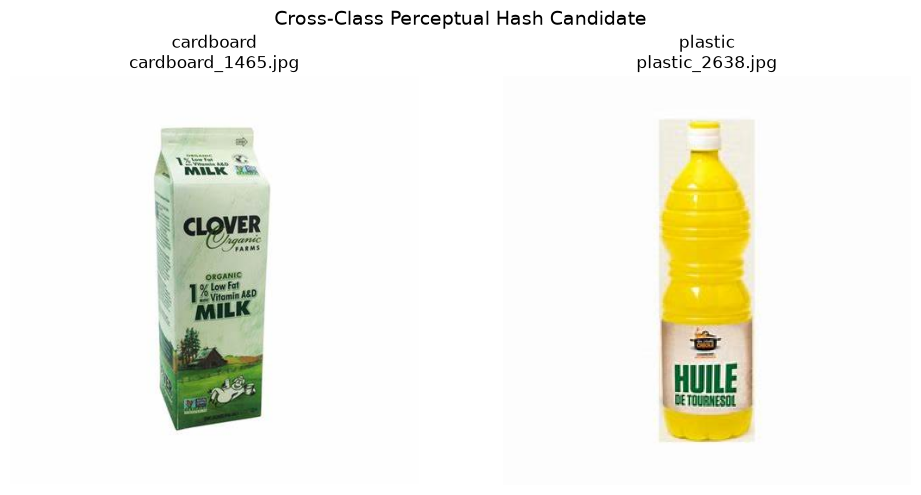

In [30]:
candidate_rows = cross_class_phash_candidates.reset_index(drop=True)

fig, axes = plt.subplots(
    1,
    len(candidate_rows),
    figsize=(10, 5)
)

if len(candidate_rows) == 1:
    axes = [axes]

for i, row in candidate_rows.iterrows():
    with Image.open(row["file_path"]) as img:
        image = img.convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(
        f"{row['class_name']}\n{row['file_name']}"
    )
    axes[i].axis("off")

plt.suptitle(
    "Cross-Class Perceptual Hash Candidate",
    fontsize=14
)

plt.tight_layout()
plt.show()

calculate their perceptual distance

In [31]:
import imagehash

hash1 = imagehash.hex_to_hash(
    candidate_rows.iloc[0]["phash"]
)

hash2 = imagehash.hex_to_hash(
    candidate_rows.iloc[1]["phash"]
)

distance = hash1 - hash2

print("Perceptual hash Hamming distance:", distance)

Perceptual hash Hamming distance: 0
